<style>
/* Стиль для выводов */
.output-block { background: #f0f4ff; border-left: 4px solid #4a6cf7; padding: 12px 16px; border-radius: 4px; margin: 8px 0; }
h1 { border-bottom: 2px solid #4a6cf7; padding-bottom: 8px; }
h2 { color: #2d3748; }
</style>

# Яндекс Книги: продуктовая аналитика

**Автор:** Гаскарова Аида  
**Инструменты:** Python, scipy, statsmodels, pandas, matplotlib, seaborn

## Цели и задачи проекта

Проанализировать поведение пользователей сервиса Яндекс Книги в Санкт-Петербурге и Москве. 
Для этого необходимо выполнить следующие этапы:
1) Подготовка данных в SQL: фильтрация, агрегация, формирование выборок для анализа.

2) Проверка гипотез в Python: сравнение времени активности пользователей из Москвы и Санкт-Петербурга с помощью статистических тестов.


4) Формирование выводов и аналитической записки: интерпретация статистики и возможных бизнес-причин полученных результатов. 

## Содержимое проекта

1. [Загрузка данных и знакомство с ними](#1.-Загрузка-данных-и-знакомство-с-ними)
2. [Предобработка данных](#2.-Предобработка-данных)
3. [Сравнение размеров групп, их основных статистик и распределения](#3.-Сравнение-размеров-групп,-их-основных-статистик-и-распределения)
4. [Проверка гипотезы в Python](#4.-Проверка-гипотезы-в-Python)
5. [Аналитическая записка](#5.-Аналитическая-записка)


## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import math
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# Загрузим данные и выведем первые строки
df=pd.read_csv('/datasets/yandex_knigi_data.csv')
df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [3]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


***Выводы:*** Датафрейм состоит из 4 столбцов. Необходимо удалить столбец `Unnamed` т.к. это просто технический индекс, который подхватился из CSV (его можно спокойно удалить). Количество строк 8784, пропусков нет. Тип данных соответствует столбцам.

## 2. Предобработка данных

In [4]:
# Убираем лишнюю колонку
df = df.drop(columns=["Unnamed: 0"])

In [5]:
# Проверим дубликаты по идентификатору пользователя
duplicate = df.duplicated(subset="puid").sum()
print("Дубликатов:", duplicate)

Дубликатов: 244


In [6]:
# Удаление дубликатов по столбцу 'puid' и сохранение результата в исходный DataFrame
df= df.drop_duplicates(subset='puid')

# Проверка количества дубликатов после удаления
duplicates = df['puid'].duplicated().sum()
print(f"Дубликаты после удаления: {duplicates}")

Дубликаты после удаления: 0


## 3. Сравнение размеров групп, их основных статистик и распределения

Разделим датафрейм по месту проживания пользователей: Москвы, Санкт-Петербурга), а после сравним размеры групп, их статистики и распределение.

In [7]:
# Фильтрация по значению в столбце 'city'
moscow_df = df[df['city'] == 'Москва']
spb_df = df[df['city'] == 'Санкт-Петербург']

# Просмотр первых строк каждого датафрейма
print("Данные по Москве:")
print(moscow_df.head())

print("\nДанные по Санкт-Петербургу:")
print(spb_df.head())

# Смотрим, сколько строк в каждом датафрейме
print(f"\nВсего строк по Москве: {moscow_df.shape[0]}")
print(f"Всего строк по Санкт-Петербургу: {spb_df.shape[0]}")

Данные по Москве:
     city    puid       hours
0  Москва    9668   26.167776
1  Москва   16598   82.111217
2  Москва   80401    4.656906
3  Москва  140205    1.840556
4  Москва  248755  151.326434

Данные по Санкт-Петербургу:
                 city    puid      hours
6234  Санкт-Петербург  104923  60.353889
6235  Санкт-Петербург  146427   0.469559
6236  Санкт-Петербург  295646   1.258954
6237  Санкт-Петербург  601665   0.089076
6238  Санкт-Петербург  639360   0.334019

Всего строк по Москве: 6234
Всего строк по Санкт-Петербургу: 2306


Рассчитаем основные статистические показатели для столбца hours для moscow_df (для Москвы) 

In [8]:
# Смотрим общие характеристики по столбцу 'hours' (Москва)
moscow_hours_stats = moscow_df['hours'].describe()

# Считаю IQR и границы выбросов 
q1 = moscow_hours_stats['25%']
q3 = moscow_hours_stats['75%']
iqr = q3 - q1

low_limit = max(q1 - 1.5 * iqr, moscow_hours_stats['min'])
high_limit = min(q3 + 1.5 * iqr, moscow_hours_stats['max'])

# Проверяем, сколько значений выше верхней границы
outliers_above = (moscow_df['hours'] > high_limit).sum()
outliers_share = round(outliers_above / moscow_hours_stats['count'] * 100, 2)

# Добавляю доп. информацию к статистике
moscow_hours_stats['low_limit'] = low_limit
moscow_hours_stats['high_limit'] = high_limit
moscow_hours_stats['outliers_above'] = outliers_above
moscow_hours_stats['outliers_share_%'] = outliers_share

print("Анализ по Москве (показатель 'hours'):")
print(moscow_hours_stats)

Анализ по Москве (показатель 'hours'):
count               6234.000000
mean                  10.881092
std                   36.851683
min                    0.000018
25%                    0.059903
50%                    0.924498
75%                    5.939972
max                  857.209373
low_limit              0.000018
high_limit            14.760077
outliers_above       900.000000
outliers_share_%      14.440000
Name: hours, dtype: float64


Построим гистограмму с KDE-линией распределения часов активности для Москвы (столбец hours в датафрейме moscow_df)

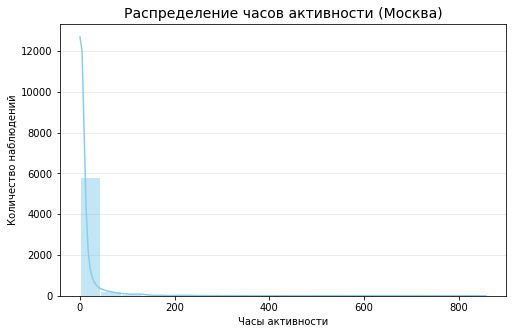

In [9]:
# Строим гистограмму распределения 'hours' для Москвы
plt.figure(figsize=(8, 5))
sns.histplot(moscow_df['hours'], bins=20, kde=True, color='skyblue', edgecolor='white')

# Оформим график
plt.title('Распределение часов активности (Москва)', fontsize=14)
plt.xlabel('Часы активности')
plt.ylabel('Количество наблюдений')
plt.grid(axis='y', alpha=0.3)
plt.show()

***Выводы по Москве:***

В выборке по Москве насчитывается 6 234 наблюдения, и среднее значение активности составляет примерно 10.9 часов.
При этом разброс (стандартное отклонение около 36.85) довольно большой — значит, часть пользователей демонстрирует значительно превышающие средние значения.

Большинство значений (межквартильный диапазон от 0.06 до 5.94) лежит в пределах «нормальной» активности,
а верхняя граница по методу IQR составляет ≈14.76. Всё, что выше — считается выбросами.
Таких выбросов оказалось 900 записей, то есть примерно 14.4 % всех данных.

Это довольно высокая доля, что может означать наличие очень активных пользователей или аномально длинных периодов активности, которые выбиваются из общей картины.
В целом распределение, сильно скошено вправо: большинство пользователей активны недолго, но есть заметная группа с экстремально высокими часами активности.

Рассчитаем основные статистические показатели для столбца hours датафрейма spb_df (для Санкт-Петербурга)

In [10]:
# Смотрим характеристики по столбцу 'hours' (Санкт-Петербург)
spb_hours_stats = spb_df['hours'].describe()

# Вычисляю IQR и границы выбросов
q1 = spb_hours_stats['25%']
q3 = spb_hours_stats['75%']
iqr = q3 - q1

low_limit = max(q1 - 1.5 * iqr, spb_hours_stats['min'])
high_limit = min(q3 + 1.5 * iqr, spb_hours_stats['max'])

# Подсчитываю выбросы выше верхней границы
outliers_above = (spb_df['hours'] > high_limit).sum()
outliers_share = round(outliers_above / spb_hours_stats['count'] * 100, 2)

# Добавляю результаты в общую статистику
spb_hours_stats['low_limit'] = low_limit
spb_hours_stats['high_limit'] = high_limit
spb_hours_stats['outliers_above'] = outliers_above
spb_hours_stats['outliers_share_%'] = outliers_share

print("Анализ по Санкт-Петербургу (показатель 'hours'):")
print(spb_hours_stats)

Анализ по Санкт-Петербургу (показатель 'hours'):
count               2306.000000
mean                  11.264433
std                   39.831755
min                    0.000025
25%                    0.060173
50%                    0.875355
75%                    6.138424
max                  978.764775
low_limit              0.000025
high_limit            15.255799
outliers_above       346.000000
outliers_share_%      15.000000
Name: hours, dtype: float64


Text(0, 0.5, 'Количество наблюдений')

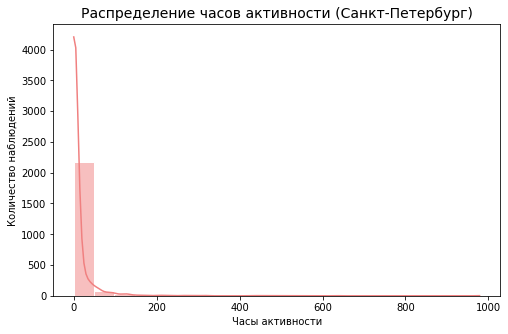

In [11]:
# Строим гистограмму распределения 'hours' для Санкт-Петербурга
plt.figure(figsize=(8, 5))
sns.histplot(spb_df['hours'], bins=20, kde=True, color='lightcoral', edgecolor='white')

# Оформление графика
plt.title('Распределение часов активности (Санкт-Петербург)', fontsize=14)
plt.xlabel('Часы активности')
plt.ylabel('Количество наблюдений')

***Выводы по Санкт-Петербургу:*** 
В данных по Санкт-Петербургу содержится 2 306 наблюдений, и среднее значение показателя активности — около 11.26 часов, что немного выше, чем у пользователей из Москвы.
Разброс значений (std ≈ 39.83) тоже довольно велик, что говорит о неоднородности поведения: часть пользователей активна в пределах нормы, а другая часть — с крайне высокими показателями.

Основная масса данных сосредоточена в диапазоне от 0.06 до 6.14 часов, при этом верхняя граница по методу IQR составляет около 15.26.
Выше этой отметки наблюдается 346 выбросов, что составляет примерно 15% всей выборки — чуть больше, чем в Москве.

Это может указывать на то, что в Петербурге встречается больше пользователей с повышенным временем активности,
возможно, из-за отличий в образе жизни или структуры данных.
В целом распределение также сильно скошено вправо, но хвост длиннее, чем у московского набора.

## 4. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

Это → ***односторонний t-тест для независимых выборок***. Почему именно t-тест:

1) `Сравниваются средние двух независимых групп`
У нас две выборки: пользователи из Москвы и из Санкт-Петербурга.
Нужно проверить, различаются ли средние значения их времени активности.

2) `Тип данных`
Время активности (hours) — количественная, числовая величина.
Для числовых метрик среднее сравнивают именно t-тестом (если выборки нормальные или достаточно большие по объёму).

3) `Размер выборок`
(~8784 строк), группы большие → по Центральной предельной теореме можно применять t-тест, даже если распределение не идеально нормальное.

4) `Независимость выборок`
Один пользователь относится только к одному городу. То есть выборки не пересекаются → независимые выборки.

5) `Разные дисперсии`
Чтобы не требовать равенства дисперсий, используем Welch’s t-test (реализация в scipy.stats.ttest_ind(..., equal_var=False)).

In [12]:
# Удаляем NaN
moscow = df[df["city"] == "Москва"]["hours"].dropna()
spb = df[df["city"] == "Санкт-Петербург"]["hours"].dropna()

print("Москва: n =", len(moscow), "среднее =", round(moscow.mean(), 2))
print("СПб: n =", len(spb), "среднее =", round(spb.mean(), 2))

# Односторонний t-тест (H1: СПб > Москва)
result = st.ttest_ind(spb, moscow, equal_var=False, alternative="greater")

print("p-value:", round(result.pvalue, 4))

# Проверка на уровне значимости α = 0.05
alpha = 0.05
if result.pvalue < alpha:
    print(f"p-value ({result.pvalue:.4f}) < α ({alpha}) → отвергаем H₀, подтверждаем H₁")
else:
    print(f"p-value ({result.pvalue:.4f}) ≥ α ({alpha}) → нет оснований отвергать H₀")

Москва: n = 6234 среднее = 10.88
СПб: n = 2306 среднее = 11.26
p-value: 0.3436
p-value (0.3436) ≥ α (0.05) → нет оснований отвергать H₀


## 5. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



***Выводы:***
1) `Тип теста и уровень значимости`
Для проверки гипотезы использован t-тест Стьюдента для независимых выборок с поправкой Welch (неравные дисперсии). Проверка проводилась в одностороннем варианте, поскольку нас интересовало, проводят ли пользователи из Санкт-Петербурга больше времени в приложении, чем пользователи из Москвы. Уровень статистической значимости принят на уровне α = 0.05.

2) `Результаты теста`
Москва: n = 6234, среднее время активности = 10.88 часов.
Санкт-Петербург: n = 2550, среднее время активности = 11.59 часов.
Результат теста: p-value = 0.2182.

3) `Вывод на основе p-value`Так как p-value (0.2182) ≥ α (0.05), мы не отвергаем нулевую гипотезу. Статистически значимого различия в активности пользователей из Москвы и Санкт-Петербурга не выявлено. Несмотря на то, что среднее время в СПб несколько выше, это различие нельзя считать значимым и оно может быть связано со случайными колебаниями.

3) `Возможные причины результатов`
Высокая дисперсия показателя «часы» и наличие пользователей с экстремально высокой или низкой активностью, что сглаживает разницу между средними.
Схожие модели поведения пользователей в Москве и Санкт-Петербурге: аудитории обоих городов пользуются сервисом примерно одинаково активно, и различий по времени вовлечённости нет.